In [1]:
import pandas as pd
import numpy as np
print("Data Uploading...")
df=pd.read_csv("accounts.csv")
data=pd.DataFrame(df)
print("Shape of the data : ",data.shape)
print("Data head : \n",data.head())

Data Uploading...
Shape of the data :  (95000, 7)
Data head : 
    account_id  customer_id  branch_id account_type   balance   open_date  \
0           1        11749        141      Current  95902.00  2019-10-20   
1           2        47716         43      Current  13261.61  2026-02-03   
2           3        56143         90      Savings  26495.92  2020-10-19   
3           4        29193        113       Salary  74682.72  2012-02-22   
4           5        49907         28      Current  40419.01  2007-01-03   

   status  
0  Active  
1  Active  
2  Active  
3  Active  
4  Active  


In [2]:
print("Data tail : \n",data.tail())

Data tail : 
        account_id  customer_id  branch_id   account_type    balance  \
94995       94996        43366         38  Fixed Deposit   66228.51   
94996       94997        50856         12        Current   39854.55   
94997       94998         8593         68        Current    9310.24   
94998       94999        49233        107  Fixed Deposit   13110.16   
94999       95000        53515         34        Savings  221443.76   

        open_date  status  
94995  2012-03-18  Closed  
94996  2011-10-21  Active  
94997  2021-03-22  Active  
94998  2009-10-16  Active  
94999  2025-08-11  Active  


In [3]:
print("All columns : \n",data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95000 entries, 0 to 94999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   account_id    95000 non-null  int64  
 1   customer_id   95000 non-null  int64  
 2   branch_id     95000 non-null  int64  
 3   account_type  95000 non-null  object 
 4   balance       95000 non-null  float64
 5   open_date     95000 non-null  object 
 6   status        95000 non-null  object 
dtypes: float64(1), int64(3), object(3)
memory usage: 5.1+ MB
All columns : 
 None


In [4]:
print(" Handling Missing Values :")
print(data.isnull().sum())
print(data.dropna())

 Handling Missing Values :
account_id      0
customer_id     0
branch_id       0
account_type    0
balance         0
open_date       0
status          0
dtype: int64
       account_id  customer_id  branch_id   account_type    balance  \
0               1        11749        141        Current   95902.00   
1               2        47716         43        Current   13261.61   
2               3        56143         90        Savings   26495.92   
3               4        29193        113         Salary   74682.72   
4               5        49907         28        Current   40419.01   
...           ...          ...        ...            ...        ...   
94995       94996        43366         38  Fixed Deposit   66228.51   
94996       94997        50856         12        Current   39854.55   
94997       94998         8593         68        Current    9310.24   
94998       94999        49233        107  Fixed Deposit   13110.16   
94999       95000        53515         34        Savi

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.svm import SVR
from sklearn.model_selection import KFold,cross_val_score,GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

In [6]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95000 entries, 0 to 94999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   account_id    95000 non-null  int64  
 1   customer_id   95000 non-null  int64  
 2   branch_id     95000 non-null  int64  
 3   account_type  95000 non-null  object 
 4   balance       95000 non-null  float64
 5   open_date     95000 non-null  object 
 6   status        95000 non-null  object 
dtypes: float64(1), int64(3), object(3)
memory usage: 5.1+ MB
None


In [7]:
print(" Simple Linear Regression :")
X=data[["account_id"]]
y=data["balance"]
print("Before Splitting :\nX shape->",X.shape)
print("y shape ->",y.shape)

 Simple Linear Regression :
Before Splitting :
X shape-> (95000, 1)
y shape -> (95000,)


In [8]:
scaler=StandardScaler()
print(" Standardizing and splitting")
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.4,random_state=42)
print("After Splitting :")
print("X_train shape -> ",X_train.shape)
print("X_test shape -> ",X_test.shape)
print("y_train shape ->",y_train.shape)
print("y_test shape ->",y_test.shape)

print("Feature Scaling :")
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
print("X_train_scaled : \n------------\n",X_train_scaled)
print("X_test_scaled : \n------------\n",X_test_scaled)

 Standardizing and splitting
After Splitting :
X_train shape ->  (57000, 1)
X_test shape ->  (38000, 1)
y_train shape -> (57000,)
y_test shape -> (38000,)
Feature Scaling :
X_train_scaled : 
------------
 [[-1.15997391]
 [ 0.78725704]
 [-1.32563299]
 ...
 [ 1.06767314]
 [-1.69610097]
 [-1.15269699]]
X_test_scaled : 
------------
 [[-0.14648092]
 [-1.18922713]
 [-0.68617367]
 ...
 [ 1.04726138]
 [ 1.06632691]
 [ 1.01029463]]


In [9]:
print(" Model training and fitting ")
model1=LinearRegression()
print("Linear Regression Model is fitted successfully\n",model1.fit(X_train_scaled,y_train))
y_pred_1=model1.predict(X_test_scaled)
print("Linear Regression Prediction : y_pred_1 ->\n",y_pred_1)


 Model training and fitting 
Linear Regression Model is fitted successfully
 LinearRegression()
Linear Regression Prediction : y_pred_1 ->
 [45562.83842034 45623.36346077 45594.16428393 ... 45493.54898068
 45492.44234328 45495.69467456]


In [10]:
print(y_test.head())

43450    26002.37
14791    69990.91
28617    28400.42
60875    33742.13
50419    84345.06
Name: balance, dtype: float64


In [11]:
print(" Linear Regression Evaluation  : ")
mae_1=mean_absolute_error(y_test,y_pred_1)
mse_1=mean_squared_error(y_test,y_pred_1)
rmse_1=np.sqrt(mse_1)
r2_1=r2_score(y_test,y_pred_1)
print("MAE : ",mae_1)
print("MSE : ",mse_1)
print("RMSE : ",rmse_1)
print("R2 : ",r2_1)

comparison=pd.DataFrame({"Linear Regression" : [mae_1,mse_1,rmse_1,r2_1]})
print(comparison)

 Linear Regression Evaluation  : 
MAE :  33368.90918563736
MSE :  2075672315.0653627
RMSE :  45559.54691461892
R2 :  -0.00013347362929105877
   Linear Regression
0       3.336891e+04
1       2.075672e+09
2       4.555955e+04
3      -1.334736e-04


Visualization : 


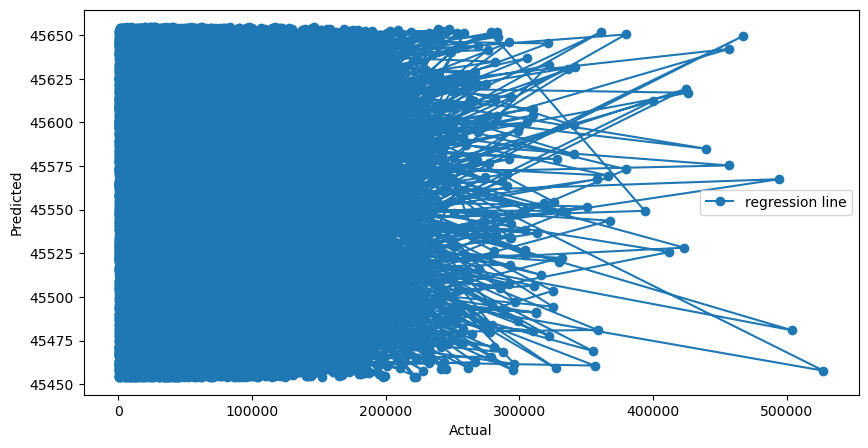

In [12]:
print("Visualization : ")
plt.figure(figsize=(10,5))
plt.plot(y_test,y_pred_1,label="regression line",marker="o")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.legend()
plt.show()

In [13]:
print("7. Multiple Linear Regression")
print("   --------------------------")
X_updated=data.drop("balance",axis=1)
y=data["balance"]
print(X_updated.shape)
print(y.shape)

7. Multiple Linear Regression
   --------------------------
(95000, 6)
(95000,)


In [14]:
print("8. Splitting the dataset into train and test ")
X_updated_train,X_updated_test,y_train,y_test=train_test_split(X_updated,y,test_size=0.4,random_state=42)
print(X_updated_train.shape)
print(X_updated_test.shape)

8. Splitting the dataset into train and test 
(57000, 6)
(38000, 6)


In [15]:
print(X_updated_train.dtypes)
print("\n",X_updated_train.info())

account_id       int64
customer_id      int64
branch_id        int64
account_type    object
open_date       object
status          object
dtype: object
<class 'pandas.core.frame.DataFrame'>
Index: 57000 entries, 15595 to 15795
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   account_id    57000 non-null  int64 
 1   customer_id   57000 non-null  int64 
 2   branch_id     57000 non-null  int64 
 3   account_type  57000 non-null  object
 4   open_date     57000 non-null  object
 5   status        57000 non-null  object
dtypes: int64(3), object(3)
memory usage: 3.0+ MB

 None


In [16]:
print("Updating the splitted datasets")
X_updated_train["open_date"]=pd.to_datetime(X_updated_train["open_date"])
X_updated_test["open_date"]=pd.to_datetime(X_updated_test["open_date"])
for df in [X_updated_train, X_updated_test]:
    df["open_year"]=df["open_date"].dt.year
    df["open_month"]=df["open_date"].dt.month
    df["open_day"]=df["open_date"].dt.day
X_updated_train=X_updated_train.drop("open_date",axis=1)
X_updated_test=X_updated_test.drop("open_date",axis=1)


Updating the splitted datasets


In [17]:
print("Encoding :")
categorical_columns=["account_type","status"]
encoder=OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False)
X_updated_train_encoded=encoder.fit_transform(X_updated_train[categorical_columns])
X_updated_test_encoded=encoder.transform(X_updated_test[categorical_columns])

Encoding :


In [18]:
model2=LinearRegression()
model2.fit(X_updated_train_encoded,y_train)
y_pred_2=model2.predict(X_updated_test_encoded)
print("Multiple Linear Regression Prections : y_pred_2 :")
print(y_pred_2)



Multiple Linear Regression Prections : y_pred_2 :
[45184. 45824. 45952. ... 45728. 45728. 45824.]


In [19]:
print("Multiple Linear Regression Evaluation : ")
mae_2=mean_absolute_error(y_test,y_pred_2)
mse_2=mean_squared_error(y_test,y_pred_2)
rmse_2=np.sqrt(mse_2)
r2_2=r2_score(y_test,y_pred_2)
print("MAE : ",mae_2)
print("MSE : ",mse_2)
print("RMSE : ",rmse_2)
print("R2 : ",r2_2)

comparison=pd.DataFrame({"Linear Regression" : [mae_1,mse_1,rmse_1,r2_1],"Multiple Linear Regression" : [mae_2,mse_2,rmse_2,r2_2]})
print(comparison)


Multiple Linear Regression Evaluation : 
MAE :  33375.39752921053
MSE :  2076159854.5978606
RMSE :  45564.89717532413
R2 :  -0.0003683876870783642
   Linear Regression  Multiple Linear Regression
0       3.336891e+04                3.337540e+04
1       2.075672e+09                2.076160e+09
2       4.555955e+04                4.556490e+04
3      -1.334736e-04               -3.683877e-04


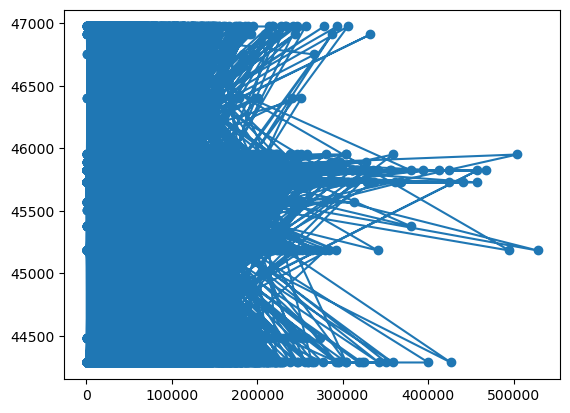

In [20]:
plt.plot(y_test,y_pred_2,marker="o")

In [21]:
print("Polynomial Regression : ")
model3=LinearRegression()
poly=PolynomialFeatures(degree=2)
X_poly_train=poly.fit_transform(X_updated_train_encoded)
X_poly_test=poly.transform(X_updated_test_encoded)
model3.fit(X_poly_train,y_train)
y_pred_3=model3.predict(X_poly_test)
print(y_pred_3)

Polynomial Regression : 
[45248. 45952. 45344. ... 44928. 44928. 45952.]


In [22]:
print("Polynomial Regression Evaluation : ")
mae_3=mean_absolute_error(y_test,y_pred_3)
mse_3=mean_squared_error(y_test,y_pred_3)
rmse_3=np.sqrt(mse_3)
r2_3=r2_score(y_test,y_pred_3)
print("MAE : ",mae_3)
print("MSE : ",mse_3)
print("RMSE : ",rmse_3)
print("R2 : ",r2_3)

comparison=pd.DataFrame({"Linear Regression" : [mae_1,mse_1,rmse_1,r2_1],"Multiple Linear Regression" : [mae_2,mse_2,rmse_2,r2_2],"Polynomial Regression" : [mae_3,mse_3,rmse_3,r2_3]})
print(comparison)


Polynomial Regression Evaluation : 
MAE :  33359.840935526314
MSE :  2076068399.3132622
RMSE :  45563.89359255048
R2 :  -0.00032432124614589775
   Linear Regression  Multiple Linear Regression  Polynomial Regression
0       3.336891e+04                3.337540e+04           3.335984e+04
1       2.075672e+09                2.076160e+09           2.076068e+09
2       4.555955e+04                4.556490e+04           4.556389e+04
3      -1.334736e-04               -3.683877e-04          -3.243212e-04


In [56]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 57000 entries, 15595 to 15795
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   account_id  57000 non-null  int64
dtypes: int64(1)
memory usage: 890.6 KB
